# 01. EDA & Preprocessing

CardioCare 프로젝트의 데이터 이해 및 전처리 단계이다.
UCI Heart Disease Cleveland 데이터를 사용하며, target은 0=정상, 1=심장병으로 이진화한다.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [11]:
columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    "../data/processed.cleveland.data",
    names=columns,
    na_values="?"
)

df["target"] = (df["target"] > 0).astype(int)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [14]:
df["target"].value_counts(normalize=True)

target
0    0.541254
1    0.458746
Name: proportion, dtype: float64

## value_counts(normalize=True)로 타깃 클래스 분포를 보고하고, 그것이 평가 지표 선택에 미치는 영향

target은 0=정상, 1=심장병을 의미한다.  
클래스 분포를 확인한 결과 두 클래스가 0.541254와 0.458746으로 완전히 동일한 비율은 아니므로, 단순 Accuracy만 사용하면 특정 클래스에 편향된 성능 해석이 발생할 수 있다.
특히 심장병 예측 문제에서는 실제 심장병 환자를 정상으로 예측하는 False Negative가 위험하므로 Recall을 중요하게 고려한다.

In [15]:
missing_by_col = df.isnull().sum()
missing_total = df.isnull().sum().sum()

print("Missing values by column:")
print(missing_by_col)

print("\nTotal missing values:", missing_total)

Missing values by column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6


In [16]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


In [17]:
empty_cols = [col for col in df.columns if df[col].isnull().all()]
empty_cols

[]

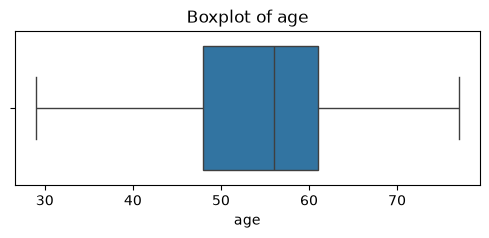

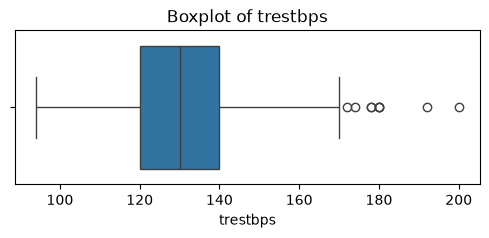

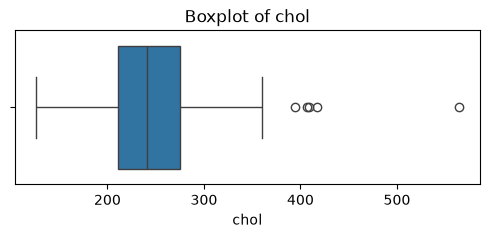

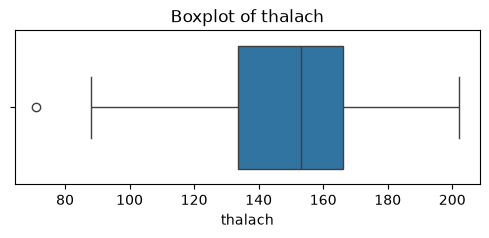

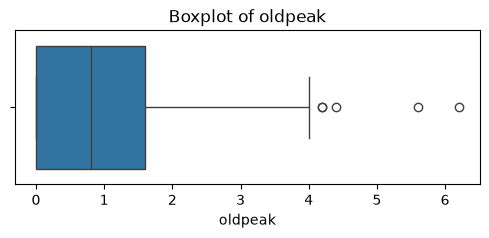

In [18]:
continuous_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

for col in continuous_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [19]:
outlier_summary = {}

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    }

pd.DataFrame(outlier_summary).T

,lower_bound,upper_bound,outlier_count
age,28.50,80.50,0.0
trestbps,90.00,170.00,9.0
chol,115.00,371.00,5.0
thalach,84.75,214.75,1.0
oldpeak,-2.40,4.00,5.0


In [25]:
class DataCleaner(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # 빈 컬럼 제거
        X = X.dropna(axis=1, how="all")

        # 중복 제거
        X = X.drop_duplicates()

        return X

In [26]:
class IQRClipper(BaseEstimator, TransformerMixin):

    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):

        self.bounds_ = {}

        for col in self.columns:

            if col in X.columns:

                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)

                IQR = Q3 - Q1

                lower = Q1 - 1.5 * IQR
                upper = Q3 + 1.5 * IQR

                self.bounds_[col] = {
                    "lower": lower,
                    "upper": upper
                }

        return self

    def transform(self, X):

        X = X.copy()

        for col, bound in self.bounds_.items():

            X[col] = X[col].clip(
                lower=bound["lower"],
                upper=bound["upper"]
            )

        return X

In [27]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [28]:
continuous_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

preprocessing_pipeline = Pipeline([

    ("cleaner", DataCleaner()),

    ("outlier_handler",
     IQRClipper(columns=continuous_cols)),

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler())

])

In [29]:
X = df.drop("target", axis=1)

X_processed = preprocessing_pipeline.fit_transform(X)

print(X_processed.shape)

(303, 13)


## EDA가 무엇을 알려 주었으며, 그에 따라 전처리에서 무엇을 어떻게 바꾸었는가?"
ca와 thal 변수에서 결측치가 발견되었으며, 데이터 수가 적기 때문에 행 삭제 대신 중앙값 대치를 적용한다

일부 연속형 변수에서 IQR 기준 이상치가 발견되었으나, 의료 데이터 특성상 임상적으로 의미 있는 값일 수 있으므로 삭제 대신 clipping을 적용한다.

중복 행과 전체가 비어 있는 컬럼은 제거한다.

모델 학습 단계에서 Logistic Regression과 SVC처럼 스케일에 민감한 모델을 사용할 예정이므로 StandardScaler를 포함한 재사용 가능한 sklearn Pipeline을 구성하였다.